In [1]:
import os
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
for candidate in (
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent,
    NOTEBOOK_CWD.parent.parent,
):
    src_dir = candidate / "src"
    if src_dir.exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break

from utils.notebook_env import configure_notebook_environment

REPO_ROOT = configure_notebook_environment()

import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import utils.comparison_utils.ostia_scenarios as ostia_scenarios
ostia_scenarios = importlib.reload(ostia_scenarios)

import utils.comparison_utils as cmp
cmp = importlib.reload(cmp)

import utils.visualization.comparison as viz_comparison
viz_comparison = importlib.reload(viz_comparison)

from utils.utils import load_json_file
import utils.visualization as viz
viz = importlib.reload(viz)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    },
)
plt.close("all")

SPLIT_PATHS_BY_RESOLUTION = {
    "mid_res": {
        "train": REPO_ROOT / "output/segmentation/8.final_results/mid_res/2026-04-30_14-33-37",
        "val": REPO_ROOT / "output/segmentation/8.final_results/mid_res/2026-04-30_13-24-40",
        "test": REPO_ROOT / "output/segmentation/8.final_results/mid_res/2026-04-19_09-10-35",
    },
    "high_res": {
        "train": REPO_ROOT / "output/segmentation/8.final_results/high_res/2026-04-21_08-42-13",
        "val": REPO_ROOT / "output/segmentation/8.final_results/high_res/2026-04-21_08-42-13",
        "test": REPO_ROOT / "output/segmentation/8.final_results/high_res/2026-04-28_14-28-44",
    },
}

VALID_SPLITS = ("train", "val", "test")

# Resultados Testes - Comparações

## Carregamento de dados

### Dados para comparação com métodos de IA

In [2]:
IA_RESULTS_BASE = REPO_ROOT / "output/ia_results"
MATH_TEST_SUMMARY_PATHS = {
    resolution: {
        split_name: split_path / f"ostios_{split_name}_summary.csv"
        for split_name, split_path in split_paths.items()
        if split_name in VALID_SPLITS
    }
    for resolution, split_paths in SPLIT_PATHS_BY_RESOLUTION.items()
}

ia_results_df, missing_ia_files = cmp.load_ia_results_for_comparison(IA_RESULTS_BASE)
math_results_df, missing_math_files = cmp.load_math_results_for_comparison(MATH_TEST_SUMMARY_PATHS)
comparison_raw_df = pd.concat([ia_results_df, math_results_df], ignore_index=True)
comparison_agg_df = cmp.build_comparison_agg_df(comparison_raw_df)

print("Shapes carregados para comparação IA:")
print("- IA:", ia_results_df.shape)
print("- Matemático:", math_results_df.shape)
print("- Consolidado:", comparison_raw_df.shape)
print("- Agregado:", comparison_agg_df.shape)

if missing_ia_files:
    print("\nAvisos IA:")
    for msg in missing_ia_files:
        print("-", msg)

if missing_math_files:
    print("\nAvisos Matemático:")
    for msg in missing_math_files:
        print("-", msg)


Shapes carregados para comparação IA:
- IA: (1400, 7)
- Matemático: (2000, 7)
- Consolidado: (3400, 7)
- Agregado: (9, 12)


### Dados de validação (30, 60 e 90 imagens)

In [3]:
path_60_val_tests = REPO_ROOT / "output/segmentation/5.val_diff/2026-03-08_15-43-56"
path_90_val_tests = REPO_ROOT / "output/segmentation/5.val_diff/2026-03-08_18-48-56"
path_30_val_tests = REPO_ROOT / "output/segmentation/8.final_results/mid_res/2026-03-27_08-43-09"

json_file_name = "ostios_val_metadata.json"
csv_file_name = "ostios_val_summary.csv"

paths_val_tests = [path_30_val_tests, path_60_val_tests, path_90_val_tests]
num_tests = [30, 60, 90]

dict_val_tests = {}

for path, num in zip(paths_val_tests, num_tests):
    json_path = path / json_file_name
    csv_path = path / csv_file_name

    json_data = load_json_file(str(json_path))
    csv_data = pd.read_csv(csv_path)

    dict_val_tests[num] = {
        "json": json_data,
        "csv": csv_data,
    }

    success_percent = cmp.get_total_success_percent(json_data)
    dice_mean = json_data.get("results_summary", {}).get("dice_artery_mean", np.nan)

    print("Percentual de óstios detectados para {} imagens: {}".format(num, success_percent))
    print("Dice médio para {} imagens: {}".format(num, dice_mean))
    print()


Percentual de óstios detectados para 30 imagens: 93.33333333333333
Dice médio para 30 imagens: 0.6510994123228695

Percentual de óstios detectados para 60 imagens: 85.0
Dice médio para 60 imagens: 0.634258141192984

Percentual de óstios detectados para 90 imagens: 86.66666666666667
Dice médio para 90 imagens: 0.6347419572961731



### Dados dos métodos de downscale

In [4]:
downscale_base_path = REPO_ROOT / "output/segmentation/1.downscale_method"
downscale_folders = sorted(
    [
        folder
        for folder in os.listdir(downscale_base_path)
        if os.path.isdir(os.path.join(downscale_base_path, folder))
    ]
)

downscale_rows = []
for folder in downscale_folders:
    metadata_path = downscale_base_path / folder / "ostios_val_metadata.json"
    if not metadata_path.exists():
        continue

    metadata = load_json_file(str(metadata_path))

    preprocessing = metadata.get("preprocessing_config", {})
    results = metadata.get("results_summary", {})

    method = preprocessing.get("downscale_method", "unknown")
    interpolation = preprocessing.get("opencv_interpolation")

    if method == "scipy":
        method_label = "SciPy (NDI)"
    else:
        interp_label = str(interpolation).upper() if interpolation else "N/A"
        method_label = f"OpenCV ({interp_label})"

    success_total_percent = cmp.get_total_success_percent(metadata)
    execution_time_seconds = cmp.get_execution_time_seconds(metadata)

    downscale_rows.append(
        {
            "metodo": method_label,
            "tempo_execucao_min": execution_time_seconds / 60 if pd.notna(execution_time_seconds) else np.nan,
            "dice_medio": results.get("dice_artery_mean", np.nan),
            "sucesso_total_percent": success_total_percent,
        }
    )

downscale_df = pd.DataFrame(downscale_rows)

method_order = ["SciPy (NDI)", "OpenCV (AREA)", "OpenCV (LINEAR)", "OpenCV (CUBIC)"]
downscale_df["metodo"] = pd.Categorical(downscale_df["metodo"], categories=method_order, ordered=True)
downscale_df = downscale_df.sort_values("metodo")

display(downscale_df)


,metodo,tempo_execucao_min,dice_medio,sucesso_total_percent
0,SciPy (NDI),105.977441,0.636033,86.666667
1,OpenCV (AREA),102.172383,0.620805,86.666667
2,OpenCV (LINEAR),101.717742,0.620805,86.666667
3,OpenCV (CUBIC),103.846065,0.622995,83.333333


## Resultados dos métodos de downscale

### Tempo de execução por método

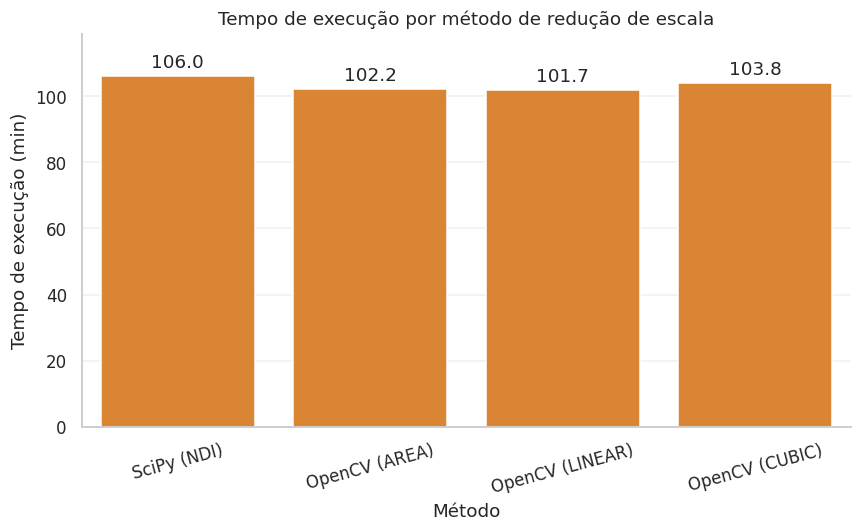

In [5]:
ax_down_time = viz.plot_downscale_execution_time(
    downscale_df=downscale_df,
    color="#F58518",
)

### Dice médio por método

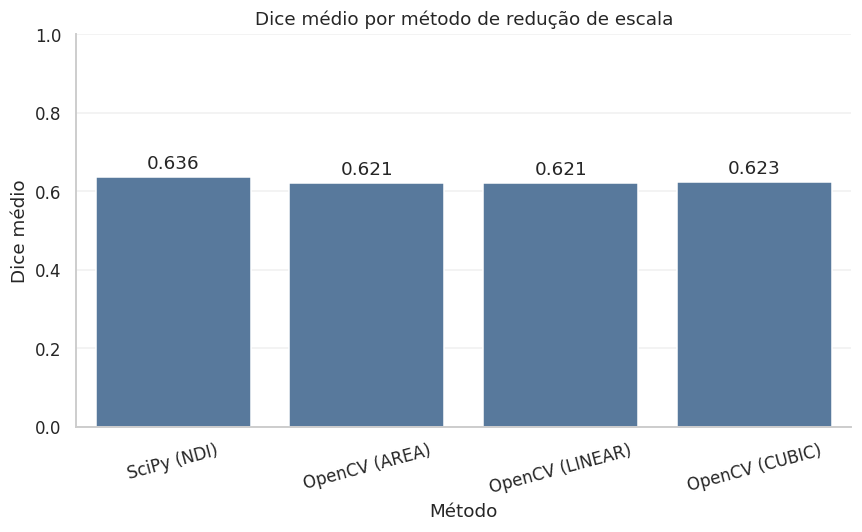

In [6]:
ax_down_dice = viz.category.plot_downscale_dice(
    downscale_df=downscale_df,
    color="#4C78A8",
)

### Sucesso na detecção dos óstios por método

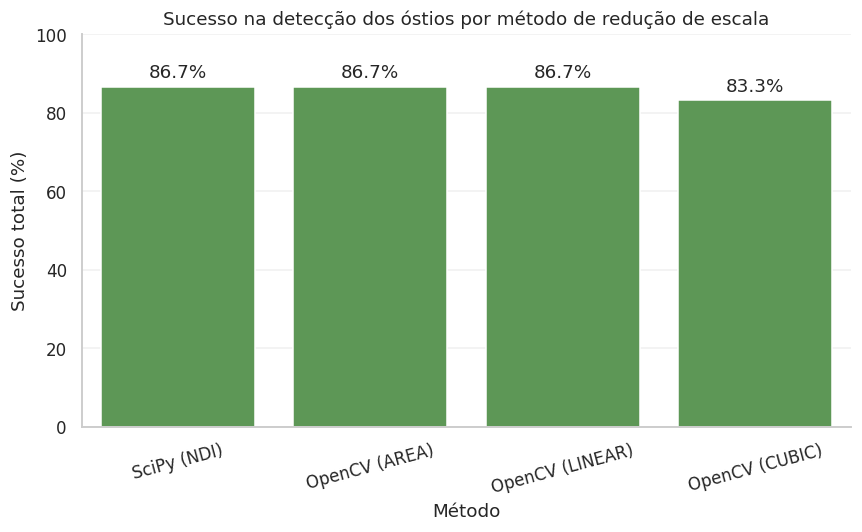

In [7]:
ax_down_success = viz.category.plot_downscale_ostia_success(
    downscale_df=downscale_df,
    color="#54A24B",
)

## Resultados por quantidade de dados de validação

### Dice médio

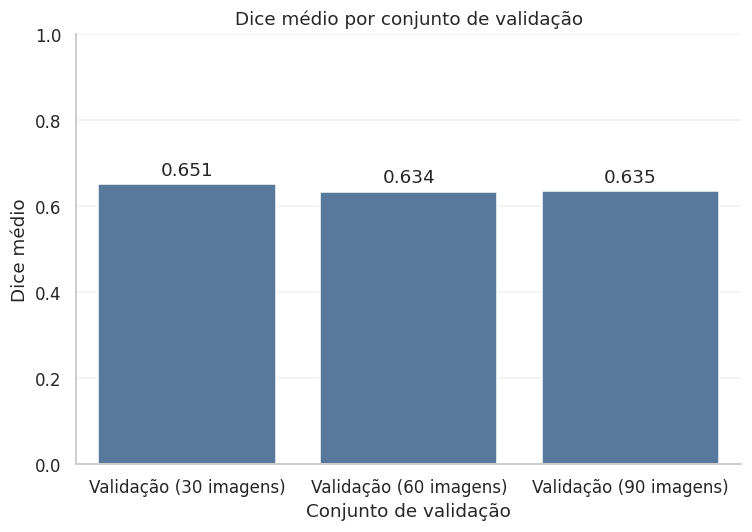

In [8]:
summary_rows = []

for num in num_tests:
    csv_df = dict_val_tests[num]["csv"].copy()
    json_df = dict_val_tests[num]["json"].copy()

    dice_scores = pd.to_numeric(csv_df["dice_artery"], errors="coerce").dropna()
    execution_time_seconds = cmp.get_execution_time_seconds(json_df)
    total_success_percent = cmp.get_total_success_percent(json_df)

    summary_rows.append(
        {
            "dataset": f"Validação ({num} imagens)",
            "dice_medio": dice_scores.mean(),
            "tempo_execucao_s": execution_time_seconds,
            "tempo_execucao_min": execution_time_seconds / 60 if pd.notna(execution_time_seconds) else np.nan,
            "sucesso_total_percent": total_success_percent,
        }
    )

summary_df = pd.DataFrame(summary_rows)

ax1 = viz.category.plot_validation_dice(
    summary_df=summary_df,
    color="#4C78A8",
)

### Tempo de execução

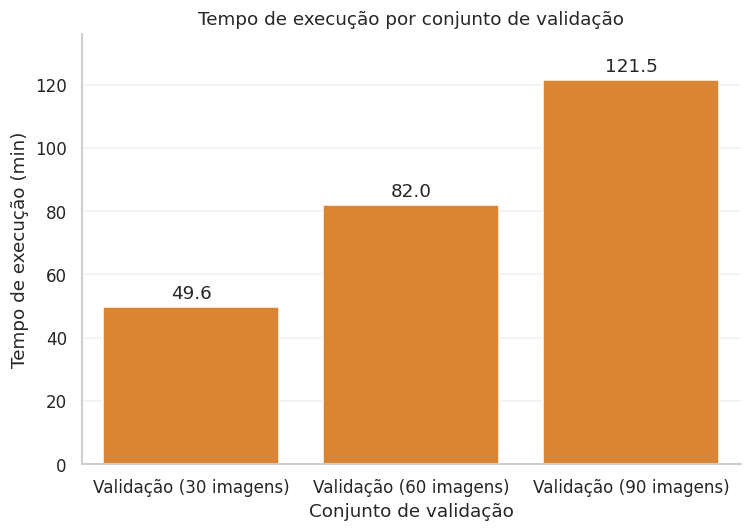

In [9]:
ax2 = viz.category.plot_validation_execution_time(
    summary_df=summary_df,
    color="#F58518",
)

### Sucesso total de detecção de óstios

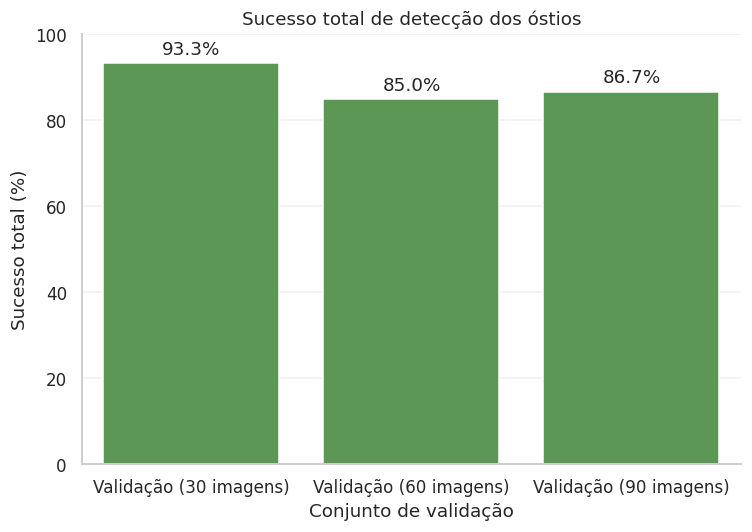

In [10]:
ax3 = viz.category.plot_validation_ostia_success(
    summary_df=summary_df,
    color="#54A24B",
)

## Comparação: Métodos de IA vs Método Matemático

In [11]:
def display_comparison_scenario(
    scenario_label,
    scenario_math_df,
    scenario_ia_df,
    scenario_missing_math_files,
    resolution,
):
    scenario_raw_df = pd.concat([scenario_ia_df, scenario_math_df], ignore_index=True)
    scenario_agg_df = cmp.build_comparison_agg_df(scenario_raw_df)

    if scenario_agg_df.empty:
        viz.plot_comparison_bar_by_resolution(
            scenario_agg_df,
            resolution,
            comparison_title=scenario_label,
        )
        return

    viz.plot_comparison_bar_by_resolution(
        scenario_agg_df,
        resolution,
        comparison_title=scenario_label,
    )

### 1. Conjunto completo de dados

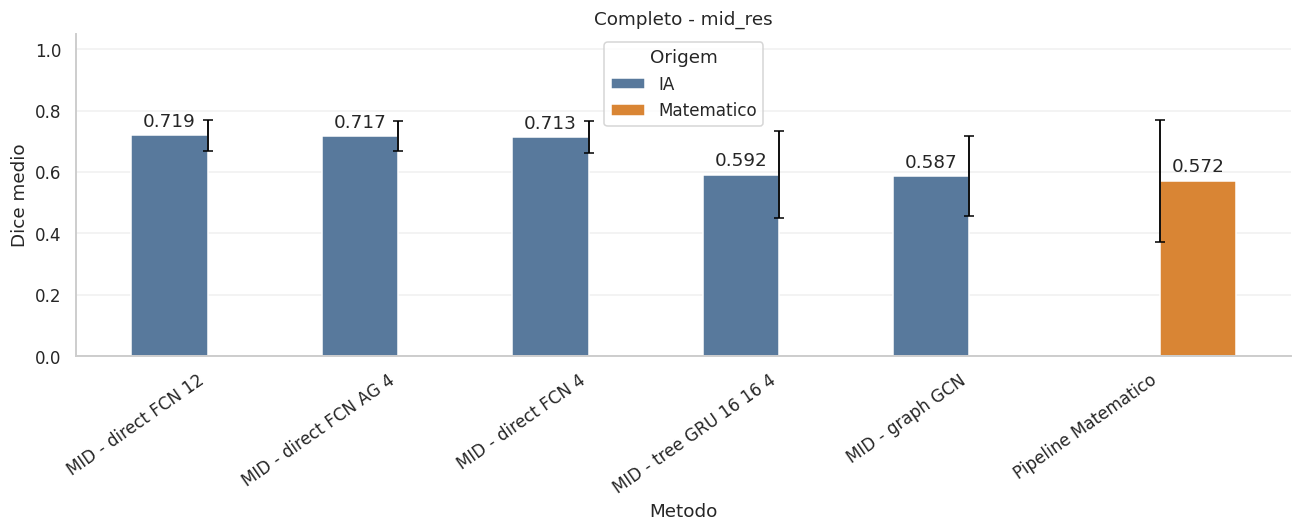

In [12]:
full_ia_df, full_math_df, full_missing_math_files = cmp.load_ostia_comparison_scenario(
    ia_results_df,
    MATH_TEST_SUMMARY_PATHS,
    "full",
)
display_comparison_scenario(
    "Completo",
    full_math_df,
    full_ia_df,
    full_missing_math_files,
    "mid_res",
)

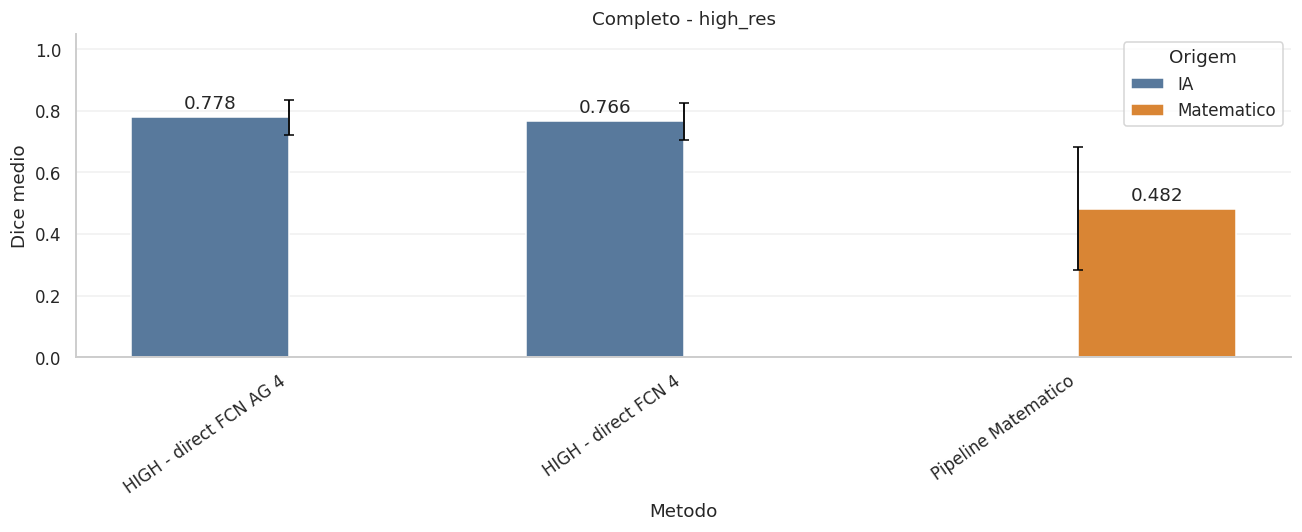

In [13]:
display_comparison_scenario(
    "Completo",
    full_math_df,
    full_ia_df,
    full_missing_math_files,
    "high_res",
)

### 2. Apenas casos em que os óstios são encontrados corretamente

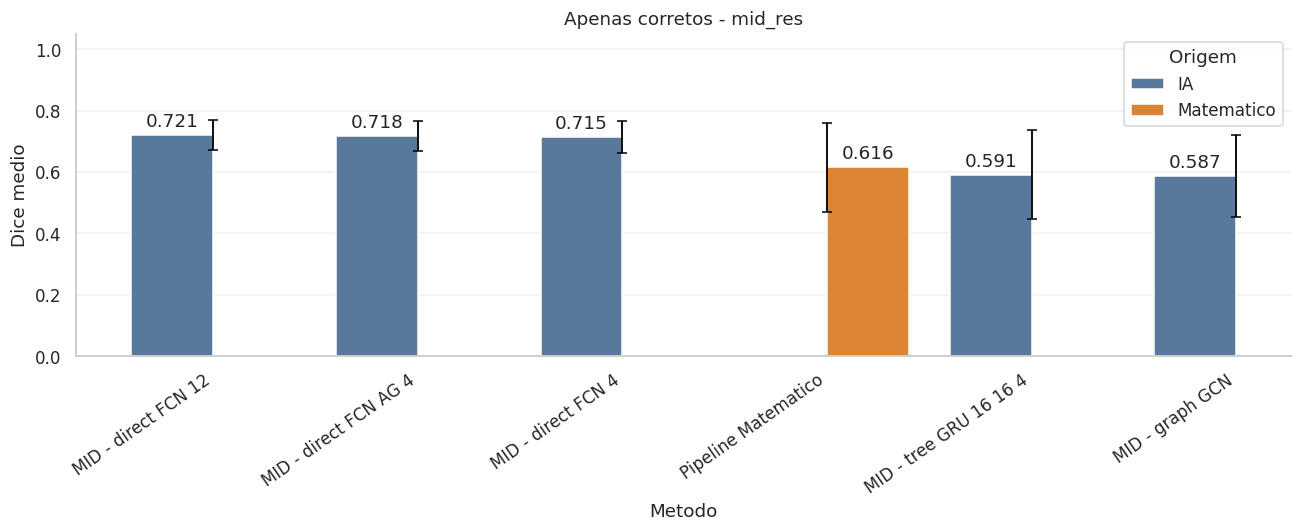

In [14]:
correct_ia_df, correct_math_df, correct_missing_math_files = cmp.load_ostia_comparison_scenario(
    ia_results_df,
    MATH_TEST_SUMMARY_PATHS,
    "correct",
)
display_comparison_scenario(
    "Apenas corretos",
    correct_math_df,
    correct_ia_df,
    correct_missing_math_files,
    "mid_res",
)

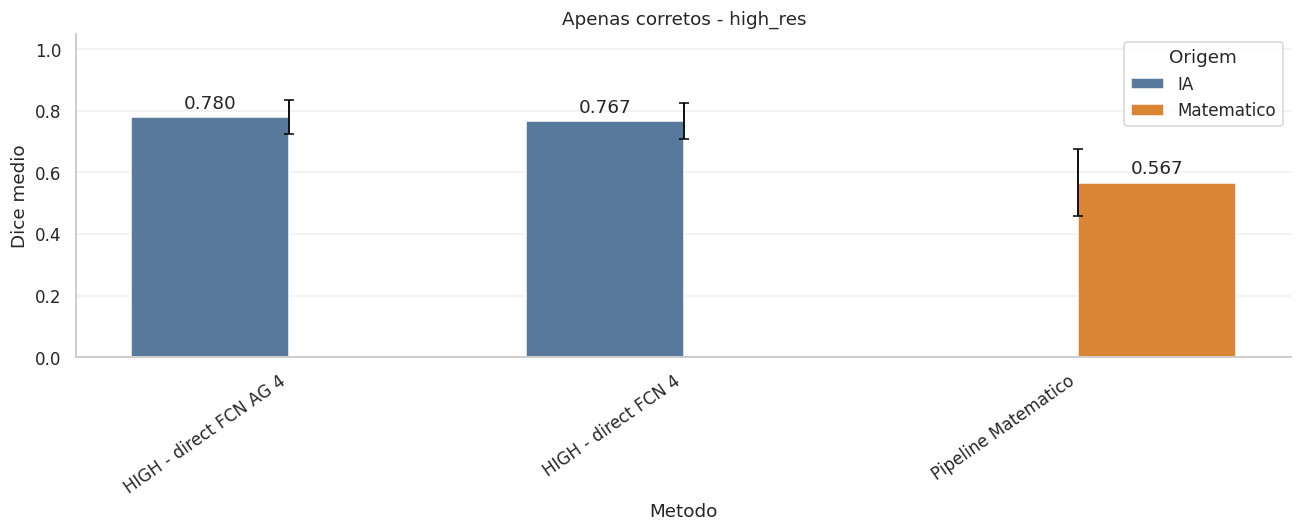

In [15]:
display_comparison_scenario(
    "Apenas corretos",
    correct_math_df,
    correct_ia_df,
    correct_missing_math_files,
    "high_res",
)

### 3. Apenas casos em que os óstios não são encontrados corretamente

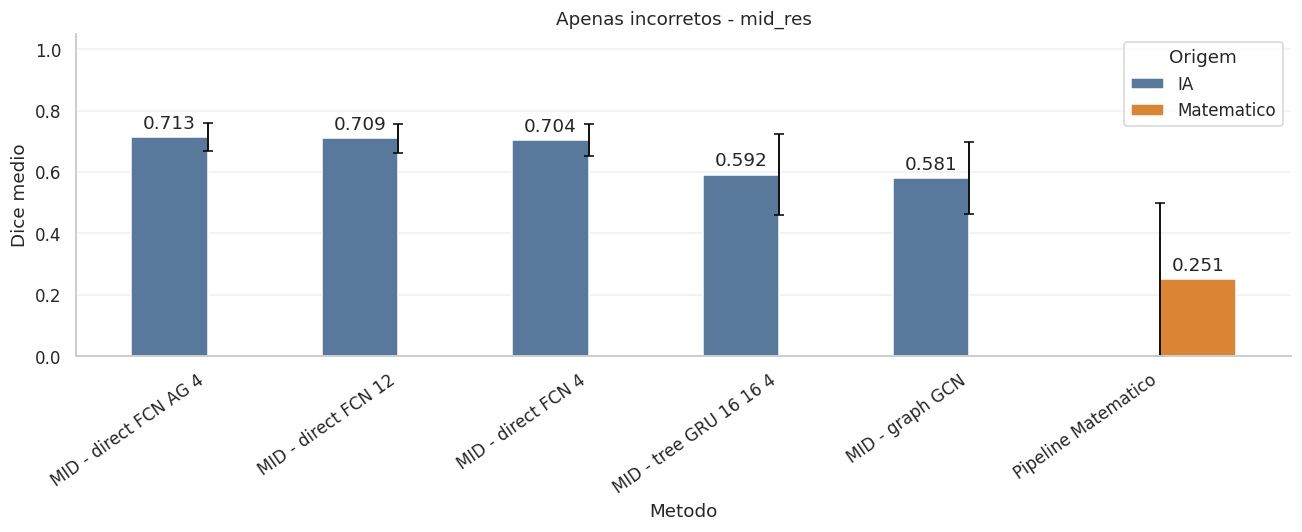

In [16]:
incorrect_ia_df, incorrect_math_df, incorrect_missing_math_files = cmp.load_ostia_comparison_scenario(
    ia_results_df,
    MATH_TEST_SUMMARY_PATHS,
    "incorrect",
)
display_comparison_scenario(
    "Apenas incorretos",
    incorrect_math_df,
    incorrect_ia_df,
    incorrect_missing_math_files,
    "mid_res",
)

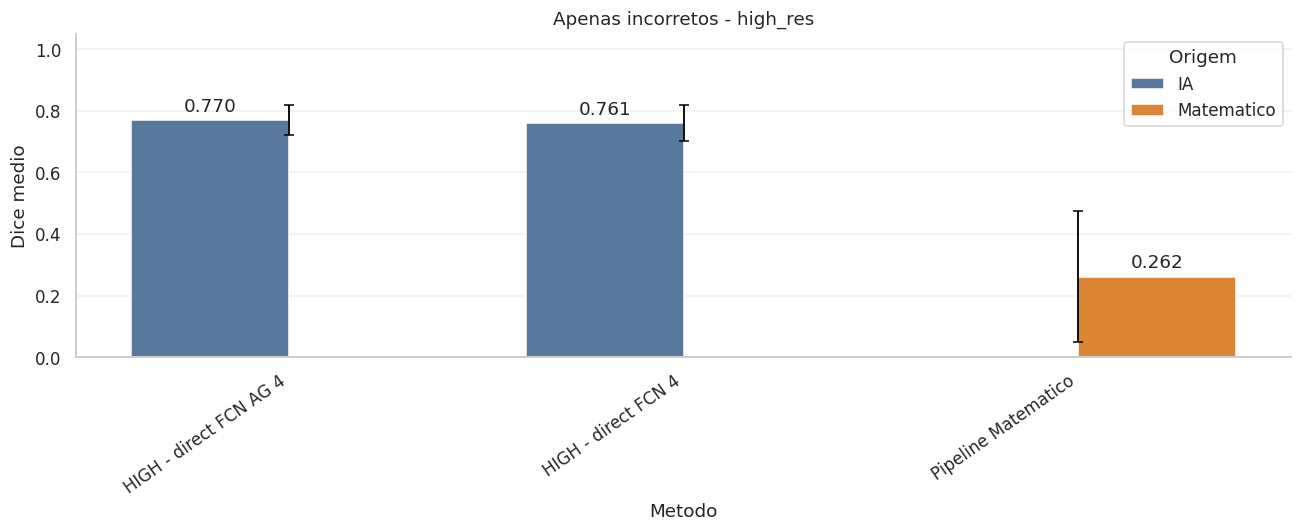

In [17]:
display_comparison_scenario(
    "Apenas incorretos",
    incorrect_math_df,
    incorrect_ia_df,
    incorrect_missing_math_files,
    "high_res",
)

## Comparação por imagem interativa: IA vs método matemático

Abaixo os gráficos interativos separados por cenário e resolução. Passe o mouse sobre os pontos para ver `img_id` e Dice.

### Completo

In [ ]:
# Completo - Mid Res
scenario_image_df = cmp.build_ostia_image_comparison_df(full_ia_df, full_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Completo")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Completo")

In [19]:
# Completo - High Res
scenario_image_df = cmp.build_ostia_image_comparison_df(full_ia_df, full_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "high_res", comparison_title="Completo")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "high_res", comparison_title="Completo")

### Apenas corretos

In [20]:
# Apenas corretos - Mid Res
scenario_image_df = cmp.build_ostia_image_comparison_df(correct_ia_df, correct_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas corretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas corretos")

In [21]:
# Apenas corretos - High Res
scenario_image_df = cmp.build_ostia_image_comparison_df(correct_ia_df, correct_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas corretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas corretos")

### Apenas incorretos

In [22]:
# Apenas incorretos - Mid Res
scenario_image_df = cmp.build_ostia_image_comparison_df(incorrect_ia_df, incorrect_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas incorretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas incorretos")

In [23]:
# Apenas incorretos - High Res
scenario_image_df = cmp.build_ostia_image_comparison_df(incorrect_ia_df, incorrect_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas incorretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas incorretos")